In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '../..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

In [2]:
import torch

In [3]:
device = torch.device('cpu') if not torch.accelerator.is_available() else torch.accelerator.current_accelerator()
print(device)

cuda


# Hyperparameters

In [4]:
batch_size = 128
resize = (96, 96)
num_epochs = 10
lr = 0.001

# Load dataset

In [5]:
from utils.data import CIFAR10, FashionMNIST
from utils.train import train_model, val_stats

def get_optimizer(model):
    return torch.optim.Adam(model.parameters(), lr=lr)

def fit(model, num_epochs=num_epochs):
    dataset = FashionMNIST(batch_size=batch_size, resize=resize, device=device)
    train_dl, val_dl = dataset.get_dataloaders()
    optimizer = get_optimizer(model)
    return train_model(model, train_dl, val_dl, optimizer, num_epochs)

# Create model

We'll be implementing the GoogLeNet (multi-branch network) architecture here.

What makes the multi-branch network different is that convolutions of multiple sizes are used at the same layer, then concatenated together. This is called an "inception" block. The main hyperparameter in each "inception" block is the number of channels used.

In [6]:
from torch import nn
import torch.nn.functional as F
from utils.models import Module

#### Inception Block

In [7]:
class Inception(nn.Module):
    def __init__(self, c1, c2, c3, c4):
        super().__init__()
        # Branch 1: 1x1 convolutions
        self.b1 = nn.LazyConv2d(c1, kernel_size=1)
        # Branch 2: 3x3 convolutions
        self.b2_1 = nn.LazyConv2d(c2[0], kernel_size=1)
        self.b2_2 = nn.LazyConv2d(c2[1], kernel_size=3, padding=1)
        # Branch 3: 5x5 convolutions
        self.b3_1 = nn.LazyConv2d(c3[0], kernel_size=1)
        self.b3_2 = nn.LazyConv2d(c3[1], kernel_size=5, padding=2)
        # Branch 4: 3x3 MaxPool layer
        self.b4_1 = nn.MaxPool2d(kernel_size=3, padding=1, stride=1)
        self.b4_2 = nn.LazyConv2d(c4, kernel_size=1)

    def forward(self, x):
        b1 = F.relu(self.b1(x))
        b2 = F.relu(self.b2_2(F.relu(self.b2_1(x))))
        b3 = F.relu(self.b3_2(F.relu(self.b3_1(x))))
        b4 = F.relu(self.b4_2(self.b4_1(x)))
        return torch.cat((b1, b2, b3, b4), dim=1)

In [8]:
class GoogLeNet(Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.num_classes = num_classes
        self.stem = nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.LazyConv2d(64, kernel_size=1), nn.ReLU(),
            nn.LazyConv2d(192, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.b1 = nn.Sequential(
            Inception(64, (96, 128), (16, 32), 32),
            Inception(128, (128, 192), (32, 96), 64),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.b2 = nn.Sequential(
            Inception(192, (96, 208), (16, 48), 64),
            Inception(160, (112, 224), (24, 64), 64),
            Inception(128, (128, 256), (24, 64), 64),
            Inception(112, (144, 288), (32, 64), 64),
            Inception(256, (160, 320), (32, 128), 128),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.b3 = nn.Sequential(
            Inception(256, (160, 320), (32, 128), 128),
            Inception(384, (192, 384), (48, 128), 128),
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten()
        )
        self.body = nn.Sequential(self.b1, self.b2, self.b3)
        self.head = nn.LazyLinear(num_classes)
        self.net = nn.Sequential(self.stem, self.body, self.head)

    def forward(self, X):
        return self.net(X)

In [9]:
model = GoogLeNet().to(device)
X = torch.randn(batch_size, 1, *resize).to(device)

In [10]:
with torch.no_grad():
    print(model(X).shape)

print(model)

torch.Size([128, 10])
GoogLeNet(
  (stem): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (4): ReLU()
    (5): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  )
  (b1): Sequential(
    (0): Inception(
      (b1): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1))
      (b2_1): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1))
      (b2_2): Conv2d(96, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (b3_1): Conv2d(192, 16, kernel_size=(1, 1), stride=(1, 1))
      (b3_2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (b4_1): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
      (b4_2): Conv2d(192, 32, ker

In [11]:
num_params = sum(p.numel() for p in model.parameters())
print(num_params)
print(f"Parameter memory: {num_params * 4 / 1e6:.0f} MB")

5977530
Parameter memory: 24 MB


# Train model

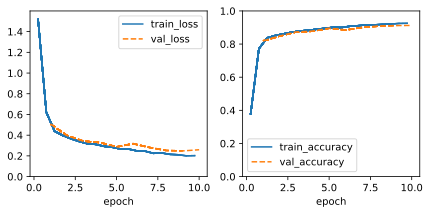

In [12]:
fit(model);

In [13]:
_, val_dl = FashionMNIST(batch_size=batch_size, resize=resize, device=device).get_dataloaders()
val_loss, val_accuracy = val_stats(model, val_dl, device=device)

In [14]:
print(f"Validation loss: {val_loss:.2f}, accuracy: {val_accuracy:.2f}%")

Validation loss: 0.26, accuracy: 0.91%


# How much memory usage during training?

In [15]:
print(f"Max memory allocated: {torch.cuda.max_memory_allocated()/1e9:.3f} GB")

Max memory allocated: 0.953 GB
